# EDA: поиск объявлений услуг

Цель — найти до 50 объявлений из benchmark-корпуса для каждого запроса. Метрика — средний по запросам Recall@50: доля выбранных пользователями объявлений, попавших в список. Порядок внутри списка на метрику не влияет.

Train содержит только положительные пары «запрос — выбранное объявление». Отрицательных меток и времени событий нет. Ниже анализируются все три входных Parquet-файла; ID трактуются как строки.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('../data/NLP_avito_interns-dataset')
QUERY_COLS = ['search_query', 'search_location_id', 'search_is_delivery_search',
              'search_infm_params_text', 'search_category']
ITEM_COLS = ['item_id', 'item_title_raw', 'item_description_raw', 'item_infm_params_text',
             'item_category_id', 'item_microcat_id', 'item_price', 'item_rating',
             'item_rating_reviews_count', 'item_location_id', 'item_latitude',
             'item_longitude', 'item_is_phone_hidden', 'item_is_message_forbidden']
train = pd.read_parquet(DATA / 'train.parquet')
benchmark_queries = pd.read_parquet(DATA / 'benchmark_queries.parquet')
benchmark_items = pd.read_parquet(DATA / 'benchmark_items.parquet')
print('train:', train.shape, 'queries:', benchmark_queries.shape,
      'items:', benchmark_items.shape)
print('Схема:', train.columns.tolist())

Matplotlib is building the font cache; this may take a moment.


train: (497673, 19) queries: (2452, 6) items: (189212, 14)
Схема: ['search_query', 'search_location_id', 'search_is_delivery_search', 'search_infm_params_text', 'search_category', 'item_title_raw', 'item_rating_reviews_count', 'item_rating', 'item_price', 'item_microcat_id', 'item_longitude', 'item_location_id', 'item_latitude', 'item_is_phone_hidden', 'item_is_message_forbidden', 'item_infm_params_text', 'item_id', 'item_description_raw', 'item_category_id']


## Структура, пропуски и значения

Числовые ID локации и категории — категориальные признаки. Цена и координаты хранятся как Decimal; для лексического baseline они не нужны. У текстов отдельно считаем пустые строки, поскольку они не являются NaN.

In [2]:
for name, frame in [('train', train), ('benchmark_queries', benchmark_queries),
                    ('benchmark_items', benchmark_items)]:
    summary = pd.DataFrame({
        'dtype': frame.dtypes.astype(str),
        'null_%': (100 * frame.isna().mean()).round(2),
        'unique': frame.nunique(dropna=True),
    })
    for col in frame.select_dtypes(include=['object', 'string']).columns:
        summary.loc[col, 'empty_%'] = round(100 * frame[col].eq('').mean(), 2)
    print('\n', name)
    display(summary)


 train


,dtype,null_%,unique,empty_%
search_query,object,0.00,74529,0.00
search_location_id,int64,0.00,2782,NaN
search_is_delivery_search,int32,0.00,2,NaN
search_infm_params_text,object,0.00,3724,32.95
search_category,int64,0.00,4,NaN
item_title_raw,object,0.00,210029,0.00
item_rating_reviews_count,float64,3.86,1372,NaN
item_rating,float64,5.67,8832,NaN
item_price,object,0.00,2992,0.00
item_microcat_id,int64,0.00,212,NaN



 benchmark_queries


,dtype,null_%,unique,empty_%
query_id,object,0.0,2452,0.00
search_query,object,0.0,2452,0.00
search_location_id,int64,0.0,273,NaN
search_is_delivery_search,int32,0.0,1,NaN
search_infm_params_text,object,0.0,132,63.05
search_category,int64,0.0,2,NaN



 benchmark_items


,dtype,null_%,unique,empty_%
item_title_raw,object,0.00,119952,0.0
item_rating_reviews_count,float64,6.14,1170,NaN
item_rating,float64,9.32,6007,NaN
item_price,object,0.00,2949,0.0
item_microcat_id,int64,0.00,752,NaN
item_longitude,object,0.00,120004,0.0
item_location_id,int64,0.00,2877,NaN
item_latitude,object,0.00,119778,0.0
item_is_phone_hidden,bool,0.00,2,NaN
item_is_message_forbidden,bool,0.00,2,NaN


## Положительные пары, дубли и пересечения

Одна строка train — одно наблюдение выбора, но одинаковые запрос и объявление могут повторяться. Для Recall@50 релевантные ID внутри контекста запроса нужно дедуплицировать. При валидации объявление из held-out пары должно присутствовать в каталоге кандидатов — как в benchmark.

In [3]:
pairs = train[QUERY_COLS + ['item_id']].drop_duplicates()
per_context = pairs.groupby(QUERY_COLS, dropna=False).size()
per_text = train.groupby('search_query').size()
train_ids = set(train.item_id)
benchmark_ids = set(benchmark_items.item_id)
print('Повторных строк по (все признаки запроса, item_id):',
      len(train) - len(pairs))
print('Уникальных контекстов:', len(per_context))
print('Релевантных ID на контекст, квантили:',
      per_context.quantile([.5, .9, .95, .99, .999, 1]).to_dict())
print('Контекстов с >50 релевантными:', int((per_context > 50).sum()))
print('Различных текстов запросов train:', per_text.size)
print('Частота текста, квантили:', per_text.quantile([.5, .9, .99, 1]).to_dict())
print('Различных train item_id:', len(train_ids), 'benchmark item_id:', len(benchmark_ids))
print('ID на пересечении:', len(train_ids & benchmark_ids),
      f'({len(train_ids & benchmark_ids)/len(benchmark_ids):.1%} benchmark-каталога)')
print('Уникальные ID и длина:',
      benchmark_items.item_id.is_unique,
      benchmark_items.item_id.str.len().value_counts().to_dict())
print('Уникальные query_id и длина:',
      benchmark_queries.query_id.is_unique,
      benchmark_queries.query_id.str.len().value_counts().to_dict())

Повторных строк по (все признаки запроса, item_id): 30619
Уникальных контекстов: 354463
Релевантных ID на контекст, квантили: {0.5: 1.0, 0.9: 2.0, 0.95: 3.0, 0.99: 6.0, 0.999: 18.0, 1.0: 278.0}
Контекстов с >50 релевантными: 42
Различных текстов запросов train: 74529
Частота текста, квантили: {0.5: 1.0, 0.9: 7.0, 0.99: 85.0, 1.0: 6540.0}
Различных train item_id: 344825 benchmark item_id: 189212
ID на пересечении: 18142 (9.6% benchmark-каталога)
Уникальные ID и длина: True {16: 189212}
Уникальные query_id и длина: True {16: 2452}


In [4]:
train_contexts = train[QUERY_COLS].drop_duplicates()
exact_context_overlap = benchmark_queries.merge(
    train_contexts, on=QUERY_COLS, how='left', indicator=True
)['_merge'].eq('both')
text_overlap = benchmark_queries.search_query.isin(train.search_query)
normalized = (benchmark_queries.search_query.str.lower()
              .str.replace(r'[^а-яёa-z0-9]+', ' ', regex=True).str.strip())
print('Benchmark: известный текст запроса:', f'{text_overlap.mean():.1%}')
print('Benchmark: совпадение полного контекста:', f'{exact_context_overlap.mean():.1%}')
print('Нормализованных дубликатов текстов внутри benchmark:', normalized.duplicated().sum())
print('Дубликатов заголовков внутри benchmark-каталога:',
      benchmark_items.item_title_raw.duplicated().sum())

Benchmark: известный текст запроса: 37.0%
Benchmark: совпадение полного контекста: 4.4%
Нормализованных дубликатов текстов внутри benchmark: 1
Дубликатов заголовков внутри benchmark-каталога: 69260


## Тексты и сдвиг train → benchmark

Сравниваем распределения по уникальным текстам train, а не только по строкам взаимодействий: иначе частые запросы доминируют. Длинные параметры объявления и описания часто содержат шаблонные поля; они полезны для редких слов, но способны размыть заголовок.

,train_unique_text,benchmark_text
0.10,13.0,13.00
0.25,16.0,17.00
0.50,22.0,22.00
0.75,27.0,28.00
0.90,34.0,35.00
0.99,46.0,47.49


train unique query Latin: 0.076 digits: 0.046 punctuation: 0.011
benchmark query Latin: 0.049 digits: 0.038 punctuation: 0.013


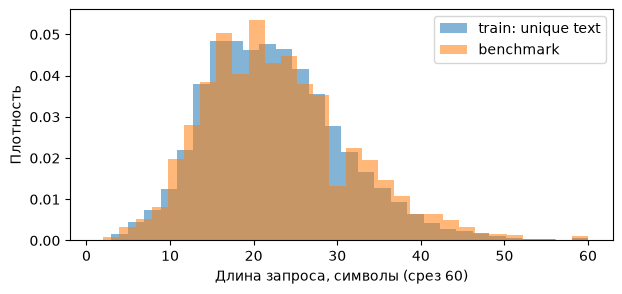

In [5]:
unique_train_text = train[['search_query']].drop_duplicates()
text_stats = pd.DataFrame({
    'train_unique_text': unique_train_text.search_query.str.len()
        .quantile([.1, .25, .5, .75, .9, .99]),
    'benchmark_text': benchmark_queries.search_query.str.len()
        .quantile([.1, .25, .5, .75, .9, .99])
})
display(text_stats)
for name, series in [('train unique query', unique_train_text.search_query),
                     ('benchmark query', benchmark_queries.search_query)]:
    print(name, 'Latin:', round(series.str.contains('[A-Za-z]').mean(), 3),
          'digits:', round(series.str.contains(r'\d').mean(), 3),
          'punctuation:', round(series.str.contains(r'[^\w\s]', regex=True).mean(), 3))
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(unique_train_text.search_query.str.len().clip(upper=60),
        bins=30, density=True, alpha=.55, label='train: unique text')
ax.hist(benchmark_queries.search_query.str.len().clip(upper=60),
        bins=30, density=True, alpha=.55, label='benchmark')
ax.set(xlabel='Длина запроса, символы (срез 60)', ylabel='Плотность')
ax.legend()
plt.show()

In [6]:
for name, frame in [('train interactions', train), ('benchmark queries', benchmark_queries)]:
    print(name,
          'empty filter:', round(frame.search_infm_params_text.eq('').mean(), 3),
          'category:', frame.search_category.value_counts(normalize=True).round(3).to_dict(),
          'delivery:', frame.search_is_delivery_search.value_counts().to_dict())
print('Совпадение search_location_id и item_location_id в train:',
      round(train.search_location_id.eq(train.item_location_id).mean(), 3))
print('Доля benchmark-запросов, у которых локация вообще есть среди item_location_id:',
      round(benchmark_queries.search_location_id.isin(benchmark_items.item_location_id).mean(), 3))
print('Топ локаций запросов benchmark:')
display(benchmark_queries.search_location_id.value_counts().head(10).to_frame('queries'))

train interactions empty filter: 0.33 category: {114: 1.0, 0: 0.0, 81: 0.0, 10: 0.0} delivery: {0: 497661, 1: 12}
benchmark queries empty filter: 0.631 category: {114: 0.909, 0: 0.091} delivery: {0: 2452}
Совпадение search_location_id и item_location_id в train: 0.831
Доля benchmark-запросов, у которых локация вообще есть среди item_location_id: 0.826
Топ локаций запросов benchmark:


,queries
search_location_id,
637640,329
653240,214
107620,119
621540,94
650400,75
633540,66
640860,50
107621,50
661420,49


In [7]:
train_items = train[ITEM_COLS].drop_duplicates('item_id')
for name, frame in [('train unique items', train_items), ('benchmark items', benchmark_items)]:
    print('\n', name)
    for col in ['item_title_raw', 'item_description_raw', 'item_infm_params_text']:
        length = frame[col].str.len()
        print(col, 'null:', round(frame[col].isna().mean(), 4),
              'len median/p90/p99:', length.quantile([.5, .9, .99]).round().tolist())
    print('category 114:', round(frame.item_category_id.eq(114).mean(), 4),
          'missing rating:', round(frame.item_rating.isna().mean(), 3))
    print('top microcategories:', frame.item_microcat_id.value_counts().head(5).to_dict())


 train unique items
item_title_raw null: 0.0 len median/p90/p99: [33.0, 48.0, 60.0]
item_description_raw null: 0.0 len median/p90/p99: [859.0, 2774.0, 5485.0]


item_infm_params_text null: 0.0 len median/p90/p99: [833.0, 2045.0, 6073.0]
category 114: 1.0 missing rating: 0.067
top microcategories: {1289835: 16415, 86470: 13057, 86467: 9157, 1289833: 8447, 2059415: 7787}

 benchmark items
item_title_raw null: 0.0 len median/p90/p99: [35.0, 48.0, 53.0]


item_description_raw null: 0.0002 len median/p90/p99: [1054.0, 3127.0, 5541.0]
item_infm_params_text null: 0.0 len median/p90/p99: [738.0, 1864.0, 4688.0]
category 114: 0.9901 missing rating: 0.093
top microcategories: {86456: 6355, 2301563: 4272, 86467: 4064, 86470: 3858, 1289835: 3696}


## Примеры неоднозначных и сложных запросов

Короткие и редкие слова, опечатки, латиница и названия моделей могут требовать символьных n-грамм. Выбор объявления может зависеть от местоположения и параметров, даже когда заголовок совпадает по смыслу.

In [8]:
examples = benchmark_queries[
    benchmark_queries.search_query.str.contains('[A-Za-z0-9]', regex=True)
    | benchmark_queries.search_query.str.len().le(8)
][['search_query', 'search_infm_params_text', 'search_location_id']].sample(
    n=12, random_state=42
)
display(examples)
display(train[['search_query', 'item_title_raw', 'item_location_id']]
        .sample(n=12, random_state=42))

,search_query,search_infm_params_text,search_location_id
1593,курсы массажа с 0,,639440
61,образ в 4 руки макияж и присеска,,653040
1071,пеноизол,Тип услуги Изоляция и утепление Вид услуги Рем...,651280
1637,замена батареи на телефоне huawei,,661420
1116,категория a3 обучение,"Вид услуги Обучение, курсы",652560
1751,сваршики,,641780
1912,категория тракториста a3 обучение,"Вид услуги Обучение, курсы",652560
2305,нарколог,Вид услуги,639530
95,кошелев,,653040
288,2d 3d ресниц классика наращивание эффекты,,637640


,search_query,item_title_raw,item_location_id
85578,брови,Требуется модель на брови,640650
318355,услуги манипулятора,"Аренда и услуги манипулятора, стрела 14 т, 14 ...",625810
474613,ремонт принтеров,Ремонт принтеров и мфу,633540
495320,ремонт кондиционеров,Обслуживание кондиционеров и сплит system,629400
383750,передержка попугаев,Передержка домашних животных,640270
3161,вспашка мотоблоком,Вспашка земли мотоблоком,637440
288654,строительные бригады,Строительная бригада / Бригада строителей,639470
17142,электрик,Электрик Услуги электрика Электромонтаж,625810
432965,предрейсовые осмотр,Лицензия.Получение лицензии.Лицензирование,631270
204548,подключение интернета в квартиру,Мастер по интернету (без посредников),657900


## Modeling implications

- 497 673 положительных взаимодействий дают 354 463 уникальных контекста запроса и 344 825 различных объявлений. Повторных пар 30 619; метрику нужно считать после дедупликации релевантных item_id. У 42 контекстов больше 50 релевантных ID, для них максимальный Recall@50 ниже единицы.
- Все 2 452 benchmark-текста уникальны. У 63,0% текста нет в train; совпадение полного контекста — лишь 4,4%. Всего 18 142 ID train встречаются в benchmark-каталоге (9,6% каталога). Это сильный аргумент в пользу поиска по признакам объявления, а не запоминания пар или ID.
- Длины запросов похожи (медиана 22 символа), но фильтр пуст в 63,1% benchmark против 33,0% строк train. В benchmark 9,1% запросов имеют search_category=0; в train их почти нет. Search-is-delivery в benchmark всегда 0. В benchmark 99,0% объявлений относятся к категории 114.
- В 83,1% train-пар совпадает ID локации, однако у 17,4% benchmark-запросов ID локации вообще отсутствует среди объявлений. Поэтому локация — мягкий приоритет, не жесткий фильтр.
- Описания и параметры длинные (медианы benchmark 1054 и 738 символов), часто шаблонные. Основной вес стоит отдать заголовку, добавив ограниченный фрагмент описания и параметров.
- **Валидация:** фиксированный holdout из 1000 разных текстов train, по одному контексту на текст; 63% контекстов без фильтра, как в benchmark. Все пары выбранного контекста — релевантные после дедупликации. Каталог — все уникальные объявления train, включая релевантные; индекс строится без меток. Считаем средний по контекстам Recall@50, отдельно по пустому/непустому фильтру. Эта оценка приближенная: train-каталог больше (344 825 против 189 212) и состоит из когда-либо выбранных объявлений, а категория 0 почти не представлена.
- **E01:** TF-IDF слова из заголовка, коротких фрагментов описания и параметров плюс символьные n-граммы заголовка. Символьный канал помогает с опечатками и вариантами написания; мягкий бонус локации использует наблюдаемое совпадение ID. Это простой и воспроизводимый классический retrieval baseline.
- **Следующие гипотезы только после LB E01:** отдельное ранжирование кандидатов с признаками локации/категории/цен/рейтинга; dense encoder для синонимов; подбор гибридного объединения по ошибкам; при достаточном сигнале — обучение на hard negatives. Популярность ID, запоминание пар и жесткий фильтр по локации плохо подходят из-за сдвига каталога и географии.
- **Бюджет 7 submissions:** №1 — baseline; №2–4 — по одной проверенной локально гипотезе из ошибок и LB; №5 — более сильная архитектура при обоснованном выигрыше; №6 — исследовательская проверка при наличии времени и ресурса; №7 — лучший подтвержденный вариант либо ансамбль. Не обязательно использовать все попытки.